In this homework, you are required to understand how the system works as a whole, adjust the code accordingly, and interpret the results correctly. The task involves modifying a few lines of code and run the whole notebook to check the results.

Please use the new workbook [[2025]_Module_04_Colab_Trading_Simulations.ipynb](https://github.com/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/04-trading-strategy-and-simulation/%5B2025%5D_Module_04_Colab_Trading_Simulations.ipynb) for all tasks. This workbook contains a clean version of the code, with hyperparameter tuning commented out and the best models hard-coded. It should take a few minutes to run on Google Colab. Before solving the problems, make sure you can run the workbook *"as is"*.

**IMPORTANT**: Every time you start a new problem, **make a fresh copy** of the notebook and start from scratch. Do **not** apply edits from previous tasks to the same notebook instance.

**HINT**: To avoid data truncation in GitHub’s UI, try one of the following:
* Open the notebook in [Colab using the GitHub link](https://colab.research.google.com/github/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/04-trading-strategy-and-simulation/%5B2025%5D_Module_04_Colab_Trading_Simulations.ipynb).
* Clone the repository locally and open the notebook in Jupyter Notebook.


---
### Question 2: Best CAGR for Random Forest Decision Rule

**What is the probability threshold for the best Random Forest decision rule?**


#### **The Idea**

The goal is to learn how to construct and interpret the `tpr_dataframe` for another model—**Random Forest**—and connect it with financial performance.

In this task, you'll define new predictors using custom probability thresholds ranging from **0.56 to 0.64**, thereby covering the full interval from **0.55 to 0.65** (two threshold-based predictors are already defined). The objective is to build a dataframe with these decision rules, following the expected pattern:

- **Higher thresholds → Higher precision**
- **Higher thresholds → Fewer total trades**

However, now you're optimizing not just for ML performance (like precision), but also for **financial results (CAGR)** and **time efficiency (average trades per day)**. These relationships aren’t always straightforward, so experimentation is key.



### Steps

0. Make **a fresh copy** of the Module 04 notebook.
1. **Comment out the scaler in preprocessing**

   The `StandardScaler` was originally used for Logistic Regression and never removed. Since Random Forest doesn't need feature scaling, the scaler biases its output.  
   ➤ *Comment it out to allow the Random Forest to perform optimally.*
   ```python
   # scaler = StandardScaler()
   # X_train_valid = scaler.fit_transform(X_train_valid)
   # X_valid = scaler.transform(X_valid)
   # X_test = scaler.transform(X_test)
   ```

2. **Reduce model depth to 14**

   To bring the Random Forest closer to a sub-optimal Decision Tree classifier, reduce its depth from 19 to 14.  
   ➤ *This helps avoid overfitting and encourages generalization.*
   ```python
   rf_best_max_depth = 14
   ```

3. **Construct the `tpr_fpr_dataframe` for the Random Forest classifier**

   - In your code:
     ```python
     # Comment out
     y_pred_test = clf_best.predict_proba(X_test)
     # Uncomment
     y_pred_test = rf_best.predict_proba(X_test)
     ```
   - The Random Forest model provides a smoother prediction probability distribution  
     *(see density plot using `sns.histplot(y_pred_test_class1)`)*.
   - The `df_scores` dataframe will now reflect Random Forest statistics.
   - Watch how **TP + FP (total trades)** decreases with higher thresholds.
   - Examine **precision and recall** at various thresholds:
     - Precision increases with higher thresholds.
     - Recall and total trades decrease.
   - ⚠️ *But beware: higher precision and fewer trades do not always result in better financial returns (CAGR).*

4. **Define new prediction columns for thresholds 0.56 to 0.64**

   Add predictors to cover the full threshold range:
   - Use names like (where xx and yy and parameters):  
     `new[predxx_rf_best_rule_yy] =  (y_pred_all_class1_array >= 0.yy).astype(int)`  

   - Continue after existing ones:  
     `new_df['pred10_rf_best_rule_55'] = (y_pred_all_class1_array >= 0.55).astype(int)`  
     `new_df['pred11_rf_best_rule_65'] = (y_pred_all_class1_array >= 0.65).astype(int)`

5. **Review the simulation results in `df_sim1_results`**

   - Identify the decision rule with:
     - **CAGR ≥ 1.1** (i.e., ~10% annual return)
     - **Avg. daily investments ≈ 5**
   - Extract the threshold value from the predictor name.
   - ✅ *It’s great to see that we can achieve strong returns with 3x less trading effort (e.g., 5 trades/day vs. 14–15).*


---

In [11]:
!pip install yfinance

In [12]:
# read files shared via google-drive-link
# https://stackoverflow.com/questions/62759748/downloading-data-from-a-shared-google-drive-link-in-google-colab

!pip uninstall gdown -y && pip install gdown
!gdown -V

Found existing installation: gdown 5.2.0
Uninstalling gdown-5.2.0:
  Successfully uninstalled gdown-5.2.0
  Using cached gdown-5.2.0-py3-none-any.whl.metadata (5.8 kB)
Using cached gdown-5.2.0-py3-none-any.whl (18 kB)
gdown 5.2.0 at /usr/local/lib/python3.11/dist-packages


In [13]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
# import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Imports form ML (Decision Trees)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

# Disable SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

In [15]:
# https://stackoverflow.com/questions/62759748/downloading-data-from-a-shared-google-drive-link-in-google-colab
# truncated data from Module 2: https://drive.google.com/file/d/1m3Qisfs2XfWk6Sw_Uk5kHLWqwQ0q8SKb/view?usp=sharing
!gdown https://drive.google.com/file/d/1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB/view?usp=sharing --fuzzy -O /content/

Downloading...
From (original): https://drive.google.com/uc?id=1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB
From (redirected): https://drive.google.com/uc?id=1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB&confirm=t&uuid=c02967a2-7d6b-48da-9aa9-d3f85646942e
To: /content/stocks_df_combined_2025_06_13.parquet.brotli
100% 130M/130M [00:01<00:00, 114MB/s]


In [16]:
# truncated
# df = pd.read_parquet("/content/stocks_df_combined_trunc_2014_2023.parquet.brotli", )

# full dataset for 33 stocks
df_full = pd.read_parquet("/content/stocks_df_combined_2025_06_13.parquet.brotli", )

In [17]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230262 entries, 0 to 5700
Columns: 203 entries, Open to growth_btc_usd_365d
dtypes: datetime64[ns](3), float64(129), int32(64), int64(5), object(2)
memory usage: 302.2+ MB


In [18]:
# growth indicators (but not future growth)
GROWTH = [g for g in df_full.keys() if (g.find('growth_')==0)&(g.find('future')<0)]
GROWTH

['growth_1d',
 'growth_3d',
 'growth_7d',
 'growth_30d',
 'growth_90d',
 'growth_365d',
 'growth_dax_1d',
 'growth_dax_3d',
 'growth_dax_7d',
 'growth_dax_30d',
 'growth_dax_90d',
 'growth_dax_365d',
 'growth_snp500_1d',
 'growth_snp500_3d',
 'growth_snp500_7d',
 'growth_snp500_30d',
 'growth_snp500_90d',
 'growth_snp500_365d',
 'growth_dji_1d',
 'growth_dji_3d',
 'growth_dji_7d',
 'growth_dji_30d',
 'growth_dji_90d',
 'growth_dji_365d',
 'growth_epi_1d',
 'growth_epi_3d',
 'growth_epi_7d',
 'growth_epi_30d',
 'growth_epi_90d',
 'growth_epi_365d',
 'growth_gold_1d',
 'growth_gold_3d',
 'growth_gold_7d',
 'growth_gold_30d',
 'growth_gold_90d',
 'growth_gold_365d',
 'growth_wti_oil_1d',
 'growth_wti_oil_3d',
 'growth_wti_oil_7d',
 'growth_wti_oil_30d',
 'growth_wti_oil_90d',
 'growth_wti_oil_365d',
 'growth_brent_oil_1d',
 'growth_brent_oil_3d',
 'growth_brent_oil_7d',
 'growth_brent_oil_30d',
 'growth_brent_oil_90d',
 'growth_brent_oil_365d',
 'growth_btc_usd_1d',
 'growth_btc_usd_3d',


In [19]:
df_full.keys()

Index(['Open', 'High', 'Low', 'Close_x', 'Volume', 'Dividends', 'Stock Splits',
       'Ticker', 'Year', 'Month',
       ...
       'growth_brent_oil_7d', 'growth_brent_oil_30d', 'growth_brent_oil_90d',
       'growth_brent_oil_365d', 'growth_btc_usd_1d', 'growth_btc_usd_3d',
       'growth_btc_usd_7d', 'growth_btc_usd_30d', 'growth_btc_usd_90d',
       'growth_btc_usd_365d'],
      dtype='object', length=203)

In [20]:
# leaving only Volume ==> generate ln(Volume)
OHLCV = ['Open','High','Low','Close_x','Volume']

In [21]:
CATEGORICAL = ['Month', 'Weekday', 'Ticker', 'ticker_type']

In [22]:
TO_PREDICT = [g for g in df_full.keys() if (g.find('future')>=0)]
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [23]:
# we define dummy variables on Dividends and Stock Splits events later, but drop the original abs. values
TO_DROP = ['Year','Date','index_x', 'index_y', 'index', 'Quarter','Close_y','Dividends','Stock Splits'] + CATEGORICAL + OHLCV
TO_DROP

['Year',
 'Date',
 'index_x',
 'index_y',
 'index',
 'Quarter',
 'Close_y',
 'Dividends',
 'Stock Splits',
 'Month',
 'Weekday',
 'Ticker',
 'ticker_type',
 'Open',
 'High',
 'Low',
 'Close_x',
 'Volume']

In [24]:
# let's define on more custom numerical features
# Add a small constant to avoid log(0)
df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x+ 1e-6))

In [25]:
# define columns on Dividends or Stock Splits
df_full['div_payout'] = (df_full.Dividends>0).astype(int)
df_full['stock_split'] = (df_full['Stock Splits']>0).astype(int)

In [26]:
# manually defined features
CUSTOM_NUMERICAL = ['SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative','volatility', 'ln_volume','div_payout','stock_split']

In [27]:
# All Supported Ta-lib indicators: https://github.com/TA-Lib/ta-lib-python/blob/master/docs/funcs.md

TECHNICAL_INDICATORS = ['adx', 'adxr', 'apo', 'aroon_1','aroon_2', 'aroonosc',
 'bop', 'cci', 'cmo','dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext',
 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix',
 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo',
 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk',
 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr',
 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase',
 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine',
 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice']

In [28]:
TECHNICAL_PATTERNS = [g for g in df_full.keys() if g.find('cdl')>=0]
print(f'Technical patterns count = {len(TECHNICAL_PATTERNS)}, examples = {TECHNICAL_PATTERNS[0:5]}')

Technical patterns count = 61, examples = ['cdl2crows', 'cdl3blackrows', 'cdl3inside', 'cdl3linestrike', 'cdl3outside']


In [29]:
MACRO = ['gdppot_us_yoy', 'gdppot_us_qoq', 'cpi_core_yoy', 'cpi_core_mom', 'FEDFUNDS',
 'DGS1', 'DGS5', 'DGS10']

In [30]:
NUMERICAL = GROWTH + TECHNICAL_INDICATORS + TECHNICAL_PATTERNS + CUSTOM_NUMERICAL + MACRO

In [31]:
# CHECK: NO OTHER INDICATORS LEFT
OTHER = [k for k in df_full.keys() if k not in OHLCV + CATEGORICAL + NUMERICAL + TO_DROP + TO_PREDICT]
OTHER

[]

In [32]:
df_full.Ticker.nunique()

33

In [33]:
# truncated df_full with 25 years of data (and defined growth variables)
df = df_full[df_full.Date>='2000-01-01']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 206 entries, Open to stock_split
dtypes: datetime64[ns](3), float64(130), int32(64), int64(7), object(2)
memory usage: 256.1+ MB


In [34]:
# tickers, min-max date, count of daily observations
df.groupby(['Ticker'])['Date'].agg(['min','max','count'])

,min,max,count
Ticker,,,
AAPL,2000-01-03,2025-06-13,6401
ACN,2001-07-19,2025-06-13,6012
AMZN,2000-01-03,2025-06-13,6401
ASML,2000-01-03,2025-06-13,6401
AVGO,2009-08-06,2025-06-13,3989
BHARTIARTL.NS,2002-07-01,2025-06-13,5698
BRK-B,2000-01-03,2025-06-13,6401
CDI.PA,2000-01-03,2025-06-13,6540
GOOG,2004-08-19,2025-06-13,5239


In [35]:
# what are the categorical features?
CATEGORICAL

['Month', 'Weekday', 'Ticker', 'ticker_type']

In [36]:
# dummy variables are not generated from Date and numeric variables

# df.loc[:,'Month'] = df['Month'].dt.strftime('%B').astype('string')

df.loc[:,'Month']= pd.to_datetime(df['Month'], format='%m').dt.strftime('%B')

df.loc[:,'Weekday'] = df['Weekday'].astype('string')
# .astype(str)

/tmp/ipython-input-2619569166.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['January' 'January' 'January' ... 'June' 'June' 'June']' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.loc[:,'Month']= pd.to_datetime(df['Month'], format='%m').dt.strftime('%B')
/tmp/ipython-input-2619569166.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<StringArray>
['0', '1', '2', '3', '4', '0', '1', '2', '3', '4',
 ...
 '0', '1', '2', '3', '4', '0', '1', '2', '3', '4']
Length: 191795, dtype: string' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[:,'Weekday'] = df['Weekday'].astype('string')


In [37]:
# define week of month
df.loc[:,'wom'] = df.Date.apply(lambda d: (d.day-1)//7 + 1)
# convert to string
df.loc[:,'wom'] = df.loc[:,'wom'].astype(str)

/tmp/ipython-input-1081537706.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1' '1' '1' ... '2' '2' '2']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,'wom'] = df.loc[:,'wom'].astype(str)


In [38]:
# check values for week-of-month (should be between 1 and 5)
df.wom.value_counts()

,count
wom,
2,45083
3,44006
4,43753
1,43557
5,15396


In [39]:
df.loc[:,'month_wom'] = df.Month + '_w' + df.wom

In [40]:
df.month_wom.value_counts()[0:2]

,count
month_wom,
June_w1,3882
February_w1,3878


In [41]:
# del wom temp variable
del df['wom']

In [42]:
# what are the categorical features?
CATEGORICAL.append('month_wom')
CATEGORICAL

['Month', 'Weekday', 'Ticker', 'ticker_type', 'month_wom']

In [43]:
# Generate dummy variables (no need for bool, let's have int32 instead)
dummy_variables = pd.get_dummies(df[CATEGORICAL], dtype='int32')

In [44]:
dummy_variables.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 115 entries, Month_April to month_wom_September_w5
dtypes: int32(115)
memory usage: 85.6 MB


In [45]:
# get dummies names in a list
DUMMIES = dummy_variables.keys().to_list()
DUMMIES

['Month_April',
 'Month_August',
 'Month_December',
 'Month_February',
 'Month_January',
 'Month_July',
 'Month_June',
 'Month_March',
 'Month_May',
 'Month_November',
 'Month_October',
 'Month_September',
 'Weekday_0',
 'Weekday_1',
 'Weekday_2',
 'Weekday_3',
 'Weekday_4',
 'Weekday_5',
 'Weekday_6',
 'Ticker_AAPL',
 'Ticker_ACN',
 'Ticker_AMZN',
 'Ticker_ASML',
 'Ticker_AVGO',
 'Ticker_BHARTIARTL.NS',
 'Ticker_BRK-B',
 'Ticker_CDI.PA',
 'Ticker_GOOG',
 'Ticker_HDB',
 'Ticker_HINDUNILVR.NS',
 'Ticker_IBN',
 'Ticker_IDEXY',
 'Ticker_INFY',
 'Ticker_ITC.NS',
 'Ticker_JPM',
 'Ticker_LICI.NS',
 'Ticker_LLY',
 'Ticker_LT.NS',
 'Ticker_MC.PA',
 'Ticker_META',
 'Ticker_MSFT',
 'Ticker_NVDA',
 'Ticker_NVO',
 'Ticker_OR.PA',
 'Ticker_RELIANCE.NS',
 'Ticker_RMS.PA',
 'Ticker_SAP',
 'Ticker_SBIN.NS',
 'Ticker_SIE.DE',
 'Ticker_TCS.NS',
 'Ticker_TTE',
 'Ticker_V',
 'ticker_type_EU',
 'ticker_type_INDIA',
 'ticker_type_US',
 'month_wom_April_w1',
 'month_wom_April_w2',
 'month_wom_April_w3',
 'mo

In [46]:
len(DUMMIES)

115

In [47]:
# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_variables], axis=1)

In [48]:
df_with_dummies[NUMERICAL+DUMMIES].info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 301 entries, growth_1d to month_wom_September_w5
dtypes: float64(121), int32(177), int64(3)
memory usage: 312.4 MB


In [49]:
def temporal_split(df, min_date, max_date, train_prop=0.7, val_prop=0.15, test_prop=0.15):
    """
    Splits a DataFrame into three buckets based on the temporal order of the 'Date' column.

    Args:
        df (DataFrame): The DataFrame to split.
        min_date (str or Timestamp): Minimum date in the DataFrame.
        max_date (str or Timestamp): Maximum date in the DataFrame.
        train_prop (float): Proportion of data for training set (default: 0.6).
        val_prop (float): Proportion of data for validation set (default: 0.2).
        test_prop (float): Proportion of data for test set (default: 0.2).

    Returns:
        DataFrame: The input DataFrame with a new column 'split' indicating the split for each row.
    """
    # Define the date intervals
    train_end = min_date + pd.Timedelta(days=(max_date - min_date).days * train_prop)
    val_end = train_end + pd.Timedelta(days=(max_date - min_date).days * val_prop)

    # Assign split labels based on date ranges
    split_labels = []
    for date in df['Date']:
        if date <= train_end:
            split_labels.append('train')
        elif date <= val_end:
            split_labels.append('validation')
        else:
            split_labels.append('test')

    # Add 'split' column to the DataFrame
    df['split'] = split_labels

    return df

In [50]:
min_date_df = df_with_dummies.Date.min()
max_date_df = df_with_dummies.Date.max()

df_with_dummies = temporal_split(df_with_dummies,
                                 min_date = min_date_df,
                                 max_date = max_date_df)

In [51]:
df_with_dummies['split'].value_counts()/len(df_with_dummies)

,count
split,
train,0.676399
test,0.163758
validation,0.159843


In [52]:
# Prepare a dataframe for ML:
  # +-inf to NaN, all NaNs to 0s
def clean_dataframe_from_inf_and_nan(df:pd.DataFrame):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    return df

In [53]:
# remove the "segmentation" problem (warning message on df performance after many joins and data transformations)
new_df = df_with_dummies.copy()

In [54]:
# Full dataframe (transformed and truncated to 25 years)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 323 entries, Open to split
dtypes: datetime64[ns](2), float64(130), int32(178), int64(7), object(5), string(1)
memory usage: 343.9+ MB


In [55]:
# check one record: it has abs. values, text, and numbers
new_df.head(1)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,month_wom_October_w2,month_wom_October_w3,month_wom_October_w4,month_wom_October_w5,month_wom_September_w1,month_wom_September_w2,month_wom_September_w3,month_wom_September_w4,month_wom_September_w5,split
3490,35.975752,36.358881,34.3283,35.726719,53228400.0,0.0,0.0,MSFT,2000,January,...,0,0,0,0,0,0,0,0,0,train


In [56]:
# time split on train/validation/test: FIXED dates of split, approx. 70%, 15%, 15% split
new_df.groupby(['split'])['Date'].agg({'min','max','count'})

,min,max,count
split,,,
test,2021-08-20,2025-06-13,31408
train,2000-01-03,2017-10-25,129730
validation,2017-10-26,2021-08-19,30657


In [57]:
# check for imbalances of growth for train/test/validation
new_df.groupby(by='split')['growth_future_30d'].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,30418.0,1.019899,0.102172,0.580332,0.955986,1.016057,1.077950,1.648934
train,129730.0,1.023864,0.123190,0.246131,0.960248,1.020585,1.083310,5.179689
validation,30657.0,1.029596,0.099908,0.461847,0.973991,1.030784,1.086687,1.783610


In [58]:
# what do we try to predict
new_df[TO_PREDICT].head(1)

,growth_future_30d,is_positive_growth_30d_future
3490,0.845576,0


In [59]:
# to be used as features
new_df[NUMERICAL+DUMMIES].head(1)

,growth_1d,growth_3d,growth_7d,growth_30d,growth_90d,growth_365d,growth_dax_1d,growth_dax_3d,growth_dax_7d,growth_dax_30d,...,month_wom_October_w1,month_wom_October_w2,month_wom_October_w3,month_wom_October_w4,month_wom_October_w5,month_wom_September_w1,month_wom_September_w2,month_wom_September_w3,month_wom_September_w4,month_wom_September_w5
3490,0.998394,0.988341,0.991494,1.372333,1.22295,2.063054,0.970196,0.983855,1.051736,1.134572,...,0,0,0,0,0,0,0,0,0,0


In [60]:
# generate manual predictions
# Let's label all prediction features with prefix "pred"
new_df['pred0_manual_cci'] = (new_df.cci>200).astype(int)
new_df['pred1_manual_prev_g1'] = (new_df.growth_30d>1).astype(int)
new_df['pred2_manual_prev_g1_and_snp'] = ((new_df['growth_30d'] > 1) & (new_df['growth_snp500_30d'] > 1)).astype(int)

In [61]:
# new manual predictions from HA
new_df['pred3_manual_dgs10_5'] = ((new_df['DGS10'] <= 4) & (new_df['DGS5'] <= 1)).astype(int)
new_df['pred4_manual_dgs10_fedfunds'] = ((new_df['DGS10'] > 4) & (new_df['FEDFUNDS'] <= 4.795)).astype(int)

In [62]:
# sample of 10 observations and predictions
new_df[['cci','growth_30d','growth_snp500_30d','pred0_manual_cci','pred1_manual_prev_g1','pred2_manual_prev_g1_and_snp','pred3_manual_dgs10_5','pred4_manual_dgs10_fedfunds','is_positive_growth_30d_future']].sample(10)

,cci,growth_30d,growth_snp500_30d,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_positive_growth_30d_future
7563,-149.737602,1.087100,1.060271,0,1,1,0,0,1
12101,-178.937333,0.968738,1.066783,0,0,0,1,0,1
2136,79.492940,1.064882,0.993301,0,1,0,0,0,1
550,177.798047,1.207732,1.049033,0,1,1,0,0,1
5070,-33.113908,1.039076,1.042584,0,1,1,0,0,1
7020,-52.270296,0.868161,0.898744,0,0,0,0,1,1
2238,56.664022,1.228087,0.974978,0,1,0,0,1,1
1533,23.619470,1.027920,0.928804,0,1,0,0,0,1
5195,225.228242,1.118657,1.006007,1,1,1,0,0,1
5982,141.768043,1.087622,1.022194,0,1,1,0,0,0


In [63]:
# List of current predictions
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred0_manual_cci',
 'pred1_manual_prev_g1',
 'pred2_manual_prev_g1_and_snp',
 'pred3_manual_dgs10_5',
 'pred4_manual_dgs10_fedfunds']

In [64]:
# Function to find all predictions (starting from 'pred'), generate is_correct (correctness of each prediction)
# and precision on TEST dataset (assuming there is df["split"] column with values 'train','validation','test'

# returns 2 lists of features: PREDICTIONS and IS_CORRECT

def get_predictions_correctness(df:pd.DataFrame, to_predict:str):
  PREDICTIONS = [k for k in df.keys() if k.startswith('pred')]
  print(f'Prediction columns founded: {PREDICTIONS}')

  # add columns is_correct_
  for pred in PREDICTIONS:
    part1 = pred.split('_')[0] # first prefix before '_'
    df[f'is_correct_{part1}'] =  (new_df[pred] == new_df[to_predict]).astype(int)

  # IS_CORRECT features set
  IS_CORRECT =  [k for k in df.keys() if k.startswith('is_correct_')]
  print(f'Created columns is_correct: {IS_CORRECT}')

  print('Precision on TEST set for each prediction:')
  # define "Precision" for ALL predictions on a Test dataset (~4 last years of trading)
  for i,column in enumerate(IS_CORRECT):
    prediction_column = PREDICTIONS[i]
    is_correct_column = column
    filter = (new_df.split=='test') & (new_df[prediction_column]==1)
    print(f'Prediction column:{prediction_column} , is_correct_column: {is_correct_column}')
    print(new_df[filter][is_correct_column].value_counts())
    print(new_df[filter][is_correct_column].value_counts()/len(new_df[filter]))
    print('---------')

  return PREDICTIONS, IS_CORRECT

In [65]:
# Function to find all predictions (starting from 'pred'), generate is_correct (correctness of each prediction)
# and precision on TEST dataset (assuming there is df["split"] column with values 'train','validation','test'

# returns 2 lists of features: PREDICTIONS and IS_CORRECT

def get_predictions_correctness(df:pd.DataFrame, to_predict:str):
  PREDICTIONS = [k for k in df.keys() if k.startswith('pred')]
  print(f'Prediction columns founded: {PREDICTIONS}')

  # add columns is_correct_
  for pred in PREDICTIONS:
    part1 = pred.split('_')[0] # first prefix before '_'
    df[f'is_correct_{part1}'] =  (new_df[pred] == new_df[to_predict]).astype(int)

  # IS_CORRECT features set
  IS_CORRECT =  [k for k in df.keys() if k.startswith('is_correct_')]
  print(f'Created columns is_correct: {IS_CORRECT}')

  print('Precision on TEST set for each prediction:')
  # define "Precision" for ALL predictions on a Test dataset (~4 last years of trading)
  for i,column in enumerate(IS_CORRECT):
    prediction_column = PREDICTIONS[i]
    is_correct_column = column
    filter = (new_df.split=='test') & (new_df[prediction_column]==1)
    print(f'Prediction column:{prediction_column} , is_correct_column: {is_correct_column}')
    print(new_df[filter][is_correct_column].value_counts())
    print(new_df[filter][is_correct_column].value_counts()/len(new_df[filter]))
    print('---------')

  return PREDICTIONS, IS_CORRECT

In [66]:
PREDICTIONS, IS_CORRECT = get_predictions_correctness(new_df, to_predict='is_positive_growth_30d_future')

Prediction columns founded: ['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp', 'pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']
Created columns is_correct: ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2', 'is_correct_pred3', 'is_correct_pred4']
Precision on TEST set for each prediction:
Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    443
0    351
Name: count, dtype: int64
is_correct_pred0
1    0.557935
0    0.442065
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    9748
0    8243
Name: count, dtype: int64
is_correct_pred1
1    0.541826
0    0.458174
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    6984
0    6383
Name: count, dtype: int64
is_correct_pred2
1    0.522481
0    0.477519
Name: count, dtype: float64
-------

In [67]:
# sample of 10 predictions vs. is_correct vs. is_positive_growth_30d_future (what we're trying to predict)
new_df[PREDICTIONS+IS_CORRECT+['is_positive_growth_30d_future']].sample(10)

,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_correct_pred0,is_correct_pred1,is_correct_pred2,is_correct_pred3,is_correct_pred4,is_positive_growth_30d_future
1021,0,0,0,0,0,0,0,0,0,0,1
7181,0,1,0,0,0,0,1,0,0,0,1
261,0,1,1,0,0,1,0,0,1,1,0
7111,0,0,0,0,0,0,0,0,0,0,1
3285,0,0,0,0,0,0,0,0,0,0,1
4139,0,0,0,0,0,0,0,0,0,0,1
2948,0,0,0,1,0,0,0,0,1,0,1
5529,0,1,1,0,0,0,1,1,0,0,1
2283,0,0,0,0,0,1,1,1,1,1,0
3204,0,1,1,0,0,1,0,0,1,1,0


In [68]:
len(new_df[new_df.split=='test'])

31408

In [69]:
# it used to be some stats
new_df[(new_df['gdppot_us_yoy'] >= 0.027) & (new_df['growth_wti_oil_30d'] <= 1.005)]

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_correct_pred0,is_correct_pred1,is_correct_pred2,is_correct_pred3,is_correct_pred4
3682,17.010899,17.547278,16.934273,16.972586,81099400.0,0.0,0.0,MSFT,2000,October,...,0,0,0,0,0,0,0,0,0,0
3683,17.106682,17.394028,16.781023,17.030056,61794000.0,0.0,0.0,MSFT,2000,October,...,0,0,0,0,0,0,0,0,0,0
3684,17.049210,17.087522,16.244640,16.608612,58323600.0,0.0,0.0,MSFT,2000,October,...,0,0,0,0,0,0,0,0,0,0
3689,16.397884,16.493666,15.191030,15.440063,119759000.0,0.0,0.0,MSFT,2000,October,...,0,0,0,0,0,0,0,0,0,0
3690,15.899824,16.072232,15.401757,15.459227,81276600.0,0.0,0.0,MSFT,2000,October,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1690,115.265769,115.265769,112.248964,112.965836,1009151.0,0.0,0.0,HINDUNILVR.NS,2002,June,...,0,0,0,0,1,1,1,1,1,0
1691,113.503511,115.773583,113.115213,113.981422,1117609.0,0.0,0.0,HINDUNILVR.NS,2002,June,...,0,0,0,0,1,1,1,1,1,0
1692,118.879979,118.879979,113.951538,114.847618,703080.0,0.0,0.0,HINDUNILVR.NS,2002,June,...,0,0,0,0,1,1,1,1,1,0
1693,115.893030,116.191724,113.145047,113.443741,1403644.0,0.0,0.0,HINDUNILVR.NS,2002,June,...,0,0,0,0,1,1,1,1,1,0


In [70]:
# Prepare a dataframe for ML:
  # +-inf to NaN, all NaNs to 0s
def clean_dataframe_from_inf_and_nan(df:pd.DataFrame):
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.fillna(0, inplace=True)
  return df

In [71]:
# Estimation/fit function (using dataframe of features X and what to predict y) --> optimising total accuracy
# max_depth is hyperParameter
def fit_decision_tree(X, y, max_depth=20):
# Initialize the Decision Tree Classifier
  clf = DecisionTreeClassifier(max_depth=max_depth,
                               random_state=42)

  # Fit the classifier to the training data
  clf.fit(X, y)
  return clf, X.columns

In [72]:
# Features to be used in predictions (incl. new dummies)
features_list = NUMERICAL+DUMMIES
# What we're trying to predict?
to_predict = 'is_positive_growth_30d_future'

train_valid_df = new_df[new_df.split.isin(['train','validation'])].copy(deep=True)
test_df = new_df[new_df.split.isin(['test'])].copy(deep=True)

# ONLY numerical Separate features and target variable for training and testing sets
X_train_valid = train_valid_df[features_list+[to_predict]]
X_test = test_df[features_list+[to_predict]]

# this to be used for predictions and join to the original dataframe new_df
X_all =  new_df[features_list+[to_predict]].copy(deep=True)

print(f'length: X_train_valid {X_train_valid.shape},  X_test {X_test.shape}, all combined: X_all {X_all.shape}')

length: X_train_valid (160387, 302),  X_test (31408, 302), all combined: X_all (191795, 302)


In [73]:
# Clean from +-inf and NaNs:

X_train_valid = clean_dataframe_from_inf_and_nan(X_train_valid)
# X_test = clean_dataframe_from_inf_and_nan(X_test) # won't use
X_all = clean_dataframe_from_inf_and_nan(X_all)

In [74]:
y_train_valid = X_train_valid[to_predict]
# y_test = X_test[to_predict] # won't use
y_all =  X_all[to_predict]

# remove y_train, y_test from X_ dataframes
del X_train_valid[to_predict]
del X_test[to_predict]
del X_all[to_predict]

In [75]:
%%time
clf_10, train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=10)

CPU times: user 28.4 s, sys: 136 ms, total: 28.5 s
Wall time: 28.6 s


In [76]:
X_train_valid.shape

(160387, 301)

In [77]:
X_all.shape

(191795, 301)

In [78]:
y_all.shape

(191795,)

In [79]:
# predict on a full dataset
y_pred_all = clf_10.predict(X_all)

In [80]:
# defining a new prediction vector is easy now, as the dimensions will match
new_df['pred5_clf_10'] = y_pred_all

In [81]:
# new prediction is added --> need to recalculate the correctness
PREDICTIONS, IS_CORRECT = get_predictions_correctness(new_df, to_predict='is_positive_growth_30d_future')

Prediction columns founded: ['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp', 'pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds', 'pred5_clf_10']
Created columns is_correct: ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2', 'is_correct_pred3', 'is_correct_pred4', 'is_correct_pred5']
Precision on TEST set for each prediction:
Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    443
0    351
Name: count, dtype: int64
is_correct_pred0
1    0.557935
0    0.442065
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    9748
0    8243
Name: count, dtype: int64
is_correct_pred1
1    0.541826
0    0.458174
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    6984
0    6383
Name: count, dtype: int64
is_correct_pred2
1    0.522481
0    0.477519

In [82]:
IS_CORRECT

['is_correct_pred0',
 'is_correct_pred1',
 'is_correct_pred2',
 'is_correct_pred3',
 'is_correct_pred4',
 'is_correct_pred5']

In [83]:
# define a new column that find the cases when only pred5 is correct
new_df['only_pred5_is_correct'] = (new_df.is_correct_pred5==new_df.is_positive_growth_30d_future) & \
                         (new_df.is_positive_growth_30d_future == 1) & \
                         (new_df.is_correct_pred0 == 0) & \
                         (new_df.is_correct_pred1 == 0) & \
                         (new_df.is_correct_pred2 == 0) & \
                         (new_df.is_correct_pred3 == 0) & \
                         (new_df.is_correct_pred4 == 0)

In [84]:
# need it to be integer and not bool
new_df['only_pred5_is_correct'] = new_df['only_pred5_is_correct'].astype(int)

In [85]:
# how many times only pred5 is correct in the TEST set?
new_df[new_df.split=='test']['only_pred5_is_correct'].sum()

np.int64(3659)

In [86]:
# let's look at the record
filter_unique_pred_5 = (new_df.split=='test') & (new_df.only_pred5_is_correct==1)

In [87]:
# sample with only Pred5 correct
new_df[filter_unique_pred_5].sample(10)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_correct_pred0,is_correct_pred1,is_correct_pred2,is_correct_pred3,is_correct_pred4,pred5_clf_10,is_correct_pred5,only_pred5_is_correct
6712,2500.080315,2527.867609,2472.872016,2482.616943,1250776.0,0.0,0.0,HINDUNILVR.NS,2022,September,...,0,0,0,0,0,0,0,1,1,1
6524,106.964664,108.644641,105.949295,107.056976,1730463.0,0.0,0.0,SIE.DE,2022,April,...,0,0,0,0,0,0,0,1,1,1
6663,101.980938,102.358437,99.045895,99.064774,1888000.0,0.0,0.0,SAP,2022,March,...,0,0,0,0,0,0,0,1,1,1
3905,233.673044,234.699520,231.827352,232.024750,5935500.0,0.0,0.0,V,2023,September,...,0,0,0,0,0,0,0,1,1,1
6175,29.120001,29.190001,29.030001,29.139999,3113800.0,0.0,0.0,IBN,2024,October,...,0,0,0,0,0,0,0,1,1,1
363,598.279732,602.242834,593.474496,594.465271,549716.0,0.0,0.0,LICI.NS,2023,November,...,0,0,0,0,0,0,0,1,1,1
10745,92.526260,93.772273,92.438646,93.655457,3642400.0,0.0,0.0,NVO,2023,December,...,0,0,0,0,0,0,0,1,1,1
4948,2968.810422,2989.111494,2935.785608,2940.026855,3734815.0,0.0,0.0,TCS.NS,2022,July,...,0,0,0,0,0,0,0,1,1,1
5423,3766.948085,3773.049953,3732.798432,3741.409668,1509050.0,0.0,0.0,TCS.NS,2024,June,...,0,0,0,0,0,0,0,1,1,1
2641,115.525528,118.183001,113.873319,116.530792,50670500.0,0.0,0.0,META,2022,November,...,0,0,0,0,0,0,0,1,1,1


In [88]:
# let's visually check that all predictions are 0, but pred5==1 (sample 10)
new_df[filter_unique_pred_5][PREDICTIONS+IS_CORRECT+['is_positive_growth_30d_future']].sample(10)

,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,pred5_clf_10,is_correct_pred0,is_correct_pred1,is_correct_pred2,is_correct_pred3,is_correct_pred4,is_correct_pred5,is_positive_growth_30d_future
12811,0,0,0,0,0,1,0,0,0,0,0,1,1
6981,0,0,0,0,0,1,0,0,0,0,0,1,1
5796,0,0,0,0,0,1,0,0,0,0,0,1,1
7151,0,0,0,0,0,1,0,0,0,0,0,1,1
5543,0,0,0,0,0,1,0,0,0,0,0,1,1
6290,0,0,0,0,0,1,0,0,0,0,0,1,1
6538,0,0,0,0,0,1,0,0,0,0,0,1,1
7328,0,0,0,0,0,1,0,0,0,0,0,1,1
5286,0,0,0,0,0,1,0,0,0,0,0,1,1
7193,0,0,0,0,0,1,0,0,0,0,0,1,1


In [89]:
# Features to be used in predictions (incl. new dummies)
features_list = NUMERICAL+DUMMIES
# What we're trying to predict?
to_predict = 'is_positive_growth_30d_future'

train_df = new_df[new_df.split.isin(['train'])].copy(deep=True)
valid_df = new_df[new_df.split.isin(['validation'])].copy(deep=True)
train_valid_df = new_df[new_df.split.isin(['train','validation'])].copy(deep=True)

test_df =  new_df[new_df.split.isin(['test'])].copy(deep=True)

# ONLY numerical Separate features and target variable for training and testing sets
X_train = train_df[features_list+[to_predict]]
X_valid = valid_df[features_list+[to_predict]]

X_train_valid = train_valid_df[features_list+[to_predict]]

X_test = test_df[features_list+[to_predict]]

# this to be used for predictions and join to the original dataframe new_df
X_all =  new_df[features_list+[to_predict]].copy(deep=True)

print(f'length: X_train {X_train.shape},  X_validation {X_valid.shape}, X_test {X_test.shape}, X_train_valid = {X_train_valid.shape},  all combined: X_all {X_all.shape}')


length: X_train (129730, 302),  X_validation (30657, 302), X_test (31408, 302), X_train_valid = (160387, 302),  all combined: X_all (191795, 302)


In [90]:
# Clean from +-inf and NaNs:

X_train = clean_dataframe_from_inf_and_nan(X_train)
X_valid = clean_dataframe_from_inf_and_nan(X_valid)
X_train_valid = clean_dataframe_from_inf_and_nan(X_train_valid)

X_test = clean_dataframe_from_inf_and_nan(X_test)

X_all = clean_dataframe_from_inf_and_nan(X_all)

In [91]:
y_train = X_train[to_predict]
y_valid = X_valid[to_predict]

y_train_valid = X_train_valid[to_predict]
y_test = X_test[to_predict]
y_all =  X_all[to_predict]

# remove y_train, y_test from X_ dataframes
del X_train[to_predict]
del X_valid[to_predict]
del X_train_valid[to_predict]

del X_test[to_predict]

del X_all[to_predict]

In [92]:
# visualisation: decision tree for a few levels (max_depth variable)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# https://stackoverflow.com/questions/20156951/how-do-i-find-which-attributes-my-tree-splits-on-when-using-scikit-learn
from sklearn.tree import export_text

In [93]:
precision_by_depth = {1: 0.5466, 2: 0.5511, 3: 0.5511, 4: 0.5511, 5: 0.6278, 6: 0.5691, 7: 0.5945, 8: 0.5891, 9: 0.5912, 10: 0.5888, 11: 0.5916, 12: 0.5855, 13: 0.5822, 14: 0.592, 15: 0.5833, 16: 0.5898, 17: 0.586, 18: 0.5861, 19: 0.5869, 20: 0.5773}

In [94]:
# Convert the dictionary to a DataFrame
df = pd.DataFrame(list(precision_by_depth.items()), columns=['max_depth', 'precision_score'])
df.loc[:,'precision_score'] = df.precision_score*100.0 # need for % visualisation

# Create the bar chart using Plotly Express
fig = px.bar(df,
             x='max_depth',
             y='precision_score',
            #  title='Precision Score vs. Max Depth for a Decision Tree',
             labels={'max_depth': 'Max Depth', 'precision_score': 'Precision Score'},
             range_y=[54, 65],
             text='precision_score')

# Update the text format to display as percentages
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')

# Center the title
fig.update_layout(title={'text': 'Precision Score vs. Max Depth for a Decision Tree', 'x': 0.5, 'xanchor': 'center'})


# Show the figure
fig.show()

In [95]:
%%time
clf_5, train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=5)


# predict on a full dataset
y_pred_all = clf_5.predict(X_all)


# defining a new prediction vector is easy now, as the dimensions will match
new_df['pred6_clf_5'] = y_pred_all

CPU times: user 16 s, sys: 301 ms, total: 16.3 s
Wall time: 16.4 s


In [96]:
# MANUAL SECOND BEST, need some complexity
# found earlier in HyperParams Tuning
best_depth = 14
best_precision = precision_by_depth[best_depth]

In [97]:
print(f'Best precision and depth = {best_depth}, precision (on test)={best_precision}')

Best precision and depth = 14, precision (on test)=0.592


In [98]:
%%time
clf_best, train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=best_depth)

CPU times: user 37.1 s, sys: 151 ms, total: 37.2 s
Wall time: 37.7 s


In [99]:
# For a DecisionTreeClassifier in scikit-learn, the concept of trainable parameters differs from that of neural networks.
# In decision trees, the parameters are the structure of the tree itself (nodes and splits) rather than weights.
# However, you can still get a sense of the model's complexity by looking at the number of nodes and leaves.

# Here's how you can get this information for your trained DecisionTreeClassifier (referred to as clf_best):

# Get the number of nodes and leaves in the tree
n_nodes = clf_best.tree_.node_count
n_leaves = clf_best.get_n_leaves()

print(f"Number of nodes: {n_nodes}")
print(f"Number of leaves: {n_leaves}")

Number of nodes: 4609
Number of leaves: 2305


In [100]:
clf_best

DecisionTreeClassifier(max_depth=14, random_state=42)

In [101]:
# predict on a full dataset
y_pred_clf_best = clf_best.predict(X_all)

In [102]:
# defining a new prediction vector is easy now, as the dimensions will match
new_df['pred7_clf_second_best'] = y_pred_clf_best

In [103]:
# new prediction is added --> need to recalculate the correctness
PREDICTIONS, IS_CORRECT = get_predictions_correctness(new_df, to_predict='is_positive_growth_30d_future')

Prediction columns founded: ['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp', 'pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds', 'pred5_clf_10', 'pred6_clf_5', 'pred7_clf_second_best']
Created columns is_correct: ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2', 'is_correct_pred3', 'is_correct_pred4', 'is_correct_pred5', 'is_correct_pred6', 'is_correct_pred7']
Precision on TEST set for each prediction:
Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    443
0    351
Name: count, dtype: int64
is_correct_pred0
1    0.557935
0    0.442065
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    9748
0    8243
Name: count, dtype: int64
is_correct_pred1
1    0.541826
0    0.458174
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    6984


In [104]:
# train a simple tree
%%time
clf_2,train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=2)

CPU times: user 6.25 s, sys: 127 ms, total: 6.38 s
Wall time: 6.35 s


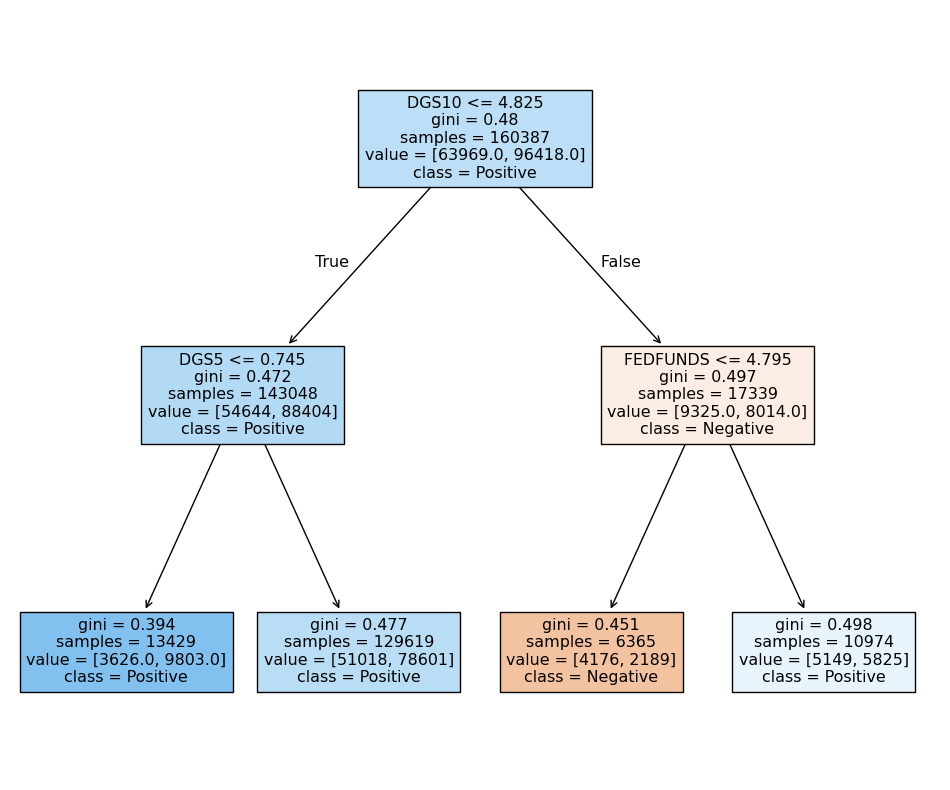

In [105]:
# Visualisation: decision tree for a few levels (max_depth variable)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming clf_2 is your trained DecisionTreeClassifier
plt.figure(figsize=(12,10))  # Set the size of the figure
plot_tree(clf_2,
          filled=True,
          feature_names=train_columns,
          class_names=['Negative', 'Positive'],
          max_depth=2)
plt.show()

In [106]:
tree_rules = export_text(clf_2, feature_names=list(X_train), max_depth=1)
print(tree_rules)

|--- DGS10 <= 4.83
|   |--- DGS5 <= 0.75
|   |   |--- class: 1
|   |--- DGS5 >  0.75
|   |   |--- class: 1
|--- DGS10 >  4.83
|   |--- FEDFUNDS <= 4.80
|   |   |--- class: 0
|   |--- FEDFUNDS >  4.80
|   |   |--- class: 1



---
### Question 2: Best CAGR for Random Forest Decision Rule

**What is the probability threshold for the best Random Forest decision rule?**


#### **The Idea**

The goal is to learn how to construct and interpret the `tpr_dataframe` for another model—**Random Forest**—and connect it with financial performance.

In this task, you'll define new predictors using custom probability thresholds ranging from **0.56 to 0.64**, thereby covering the full interval from **0.55 to 0.65** (two threshold-based predictors are already defined). The objective is to build a dataframe with these decision rules, following the expected pattern:

- **Higher thresholds → Higher precision**
- **Higher thresholds → Fewer total trades**

However, now you're optimizing not just for ML performance (like precision), but also for **financial results (CAGR)** and **time efficiency (average trades per day)**. These relationships aren’t always straightforward, so experimentation is key.



### Steps

0. Make **a fresh copy** of the Module 04 notebook.
1. **Comment out the scaler in preprocessing**

   The `StandardScaler` was originally used for Logistic Regression and never removed. Since Random Forest doesn't need feature scaling, the scaler biases its output.  
   ➤ *Comment it out to allow the Random Forest to perform optimally.*
   ```python
   # scaler = StandardScaler()
   # X_train_valid = scaler.fit_transform(X_train_valid)
   # X_valid = scaler.transform(X_valid)
   # X_test = scaler.transform(X_test)
   ```

2. **Reduce model depth to 14**

   To bring the Random Forest closer to a sub-optimal Decision Tree classifier, reduce its depth from 19 to 14.  
   ➤ *This helps avoid overfitting and encourages generalization.*
   ```python
   rf_best_max_depth = 14
   ```

3. **Construct the `tpr_fpr_dataframe` for the Random Forest classifier**

   - In your code:
     ```python
     # Comment out
     y_pred_test = clf_best.predict_proba(X_test)
     # Uncomment
     y_pred_test = rf_best.predict_proba(X_test)
     ```
   - The Random Forest model provides a smoother prediction probability distribution  
     *(see density plot using `sns.histplot(y_pred_test_class1)`)*.
   - The `df_scores` dataframe will now reflect Random Forest statistics.
   - Watch how **TP + FP (total trades)** decreases with higher thresholds.
   - Examine **precision and recall** at various thresholds:
     - Precision increases with higher thresholds.
     - Recall and total trades decrease.
   - ⚠️ *But beware: higher precision and fewer trades do not always result in better financial returns (CAGR).*

4. **Define new prediction columns for thresholds 0.56 to 0.64**

   Add predictors to cover the full threshold range:
   - Use names like (where xx and yy and parameters):  
     `new[predxx_rf_best_rule_yy] =  (y_pred_all_class1_array >= 0.yy).astype(int)`  

   - Continue after existing ones:  
     `new_df['pred10_rf_best_rule_55'] = (y_pred_all_class1_array >= 0.55).astype(int)`  
     `new_df['pred11_rf_best_rule_65'] = (y_pred_all_class1_array >= 0.65).astype(int)`

5. **Review the simulation results in `df_sim1_results`**

   - Identify the decision rule with:
     - **CAGR ≥ 1.1** (i.e., ~10% annual return)
     - **Avg. daily investments ≈ 5**
   - Extract the threshold value from the predictor name.
   - ✅ *It’s great to see that we can achieve strong returns with 3x less trading effort (e.g., 5 trades/day vs. 14–15).*


---

In [107]:
from sklearn.ensemble import RandomForestClassifier
import time

In [108]:
best_precision_matrix_random_forest = best_precision_matrix_random_forest = {
    (5, 10): 0.5498,
    (5, 50): 0.5511,
    (5, 100): 0.5511,
    (5, 200): 0.5511,
    (7, 10): 0.5540,
    (7, 50): 0.5492,
    (7, 100): 0.5495,
    (7, 200): 0.5515,
    (9, 10): 0.5411,
    (9, 50): 0.5461,
    (9, 100): 0.5507,
    (9, 200): 0.5517,
    (11, 10): 0.5623,
    (11, 50): 0.5559,
    (11, 100): 0.5565,
    (11, 200): 0.5521,
    (13, 10): 0.5510,
    (13, 50): 0.5591,
    (13, 100): 0.5614,
    (13, 200): 0.5575,
    (15, 10): 0.5596,
    (15, 50): 0.5592,
    (15, 100): 0.5585,
    (15, 200): 0.5505,
    (17, 10): 0.5538,
    (17, 50): 0.5543,
    (17, 100): 0.5510,
    (17, 200): 0.5493,
    (19, 10): 0.5611,
    (19, 50): 0.5559,
    (19, 100): 0.5599,
    (19, 200): 0.5544,
}

In [109]:
# Convert data to DataFrame
df = pd.DataFrame.from_dict(best_precision_matrix_random_forest, orient='index', columns=['precision_score']).reset_index()

# Rename the columns for clarity
df.columns = ['max_depth_and_metric', 'precision_score']

# Separate the tuple into two columns
df[['max_depth', 'n_estimators']] = pd.DataFrame(df['max_depth_and_metric'].tolist(), index=df.index)

# Drop the combined column
df = df.drop(columns=['max_depth_and_metric'])

# Create line plot using Plotly Express
fig = px.line(df, x='max_depth', y='precision_score', color='n_estimators',
              labels={'max_depth': 'Max Depth', 'precision_score': 'Precision Score', 'n_estimators': 'Number of Estimators'},
              title='Random Forest Models: Precision Score vs. Max Depth for Different Number of Estimators')

# Adjust x-axis range
fig.update_xaxes(range=[5, 20])

# Show the figure
fig.show()

In [110]:
# MANUALLY SELECTED BEST - should have enough complexity and smoothness (n_estimators)
rf_best_n_estimators = 50
# MANUALLY SELECTED BEST - should have enough complexity
rf_best_max_depth = 14

In [111]:
%%time

#
# several minutes to compute (2 min)

rf_best = RandomForestClassifier(n_estimators = rf_best_n_estimators,
                                 max_depth = rf_best_max_depth,
                                 random_state = 42,
                                 n_jobs = -1)

rf_best = rf_best.fit(X_train_valid, y_train_valid)

CPU times: user 1min 38s, sys: 377 ms, total: 1min 39s
Wall time: 57.7 s


In [112]:
new_df['proba_rf'] = rf_best.predict_proba(X_all)[:,1]
new_df['pred_rf'] = rf_best.predict(X_all)

In [113]:
y_pred_proba = rf_best.predict_proba(X_test)[:,1]

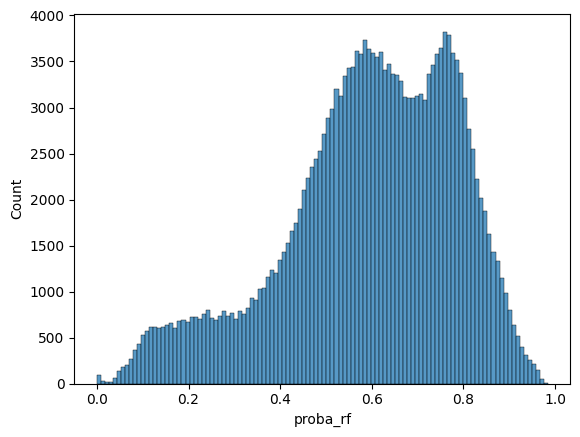

In [114]:
sns.histplot(new_df['proba_rf']);

In [115]:
def tpr_fpr_dataframe(y_true, y_pred, only_even=False):
    scores = []

    if only_even==False:
      thresholds = np.linspace(0, 1, 101) #[0, 0.01, 0.02, ...0.99,1.0]
    else:
      thresholds = np.linspace(0, 1, 51) #[0, 0.02, 0.04,  ...0.98,1.0]

    for t in thresholds:

        actual_positive = (y_true == 1)
        actual_negative = (y_true == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        if tp + fp > 0:
          precision = tp / (tp + fp)

        if tp + fn > 0:
          recall = tp / (tp + fn)

        if precision+recall > 0:
          f1_score = 2*precision*recall / (precision+recall)

        accuracy = (tp+tn) / (tp+tn+fp+fn)

        scores.append((t, tp, fp, fn, tn, precision, recall, accuracy, f1_score))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn','precision','recall', 'accuracy','f1_score']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores

In [116]:
df_scores = tpr_fpr_dataframe(y_test, y_pred_proba, only_even=True)
df_scores

,threshold,tp,fp,fn,tn,precision,recall,accuracy,f1_score,tpr,fpr
0,0.00,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
1,0.02,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
2,0.04,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
3,0.06,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
4,0.08,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
5,0.10,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
6,0.12,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
7,0.14,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
8,0.16,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000
9,0.18,17308,14100,0,0,0.551070,1.000000,0.551070,0.710567,1.000000,1.000000


<Axes: title={'center': 'Precision vs. Recall for the Best Model (Decision Tree with max_depth=14)'}, xlabel='threshold'>

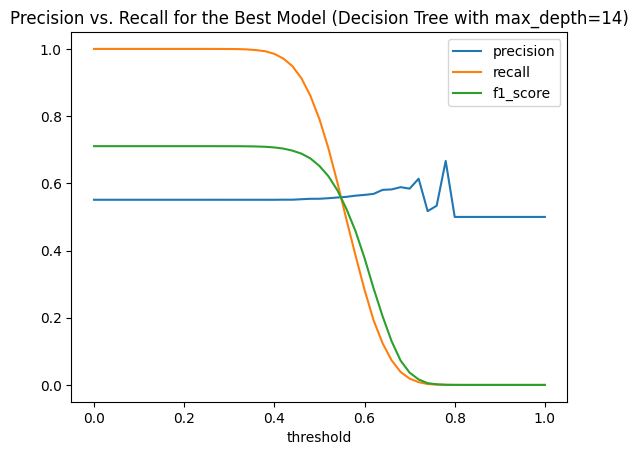

In [117]:
df_scores.plot.line(x='threshold',
                    y=['precision','recall', 'f1_score'],
                    title = 'Precision vs. Recall for the Best Model (Decision Tree with max_depth=14)')

In [118]:
thresholds = list(range(55,66))
for threshold in thresholds:
    new_df[f'pred_rf_{threshold}'] = (new_df['proba_rf'] >= threshold/100).astype(int)

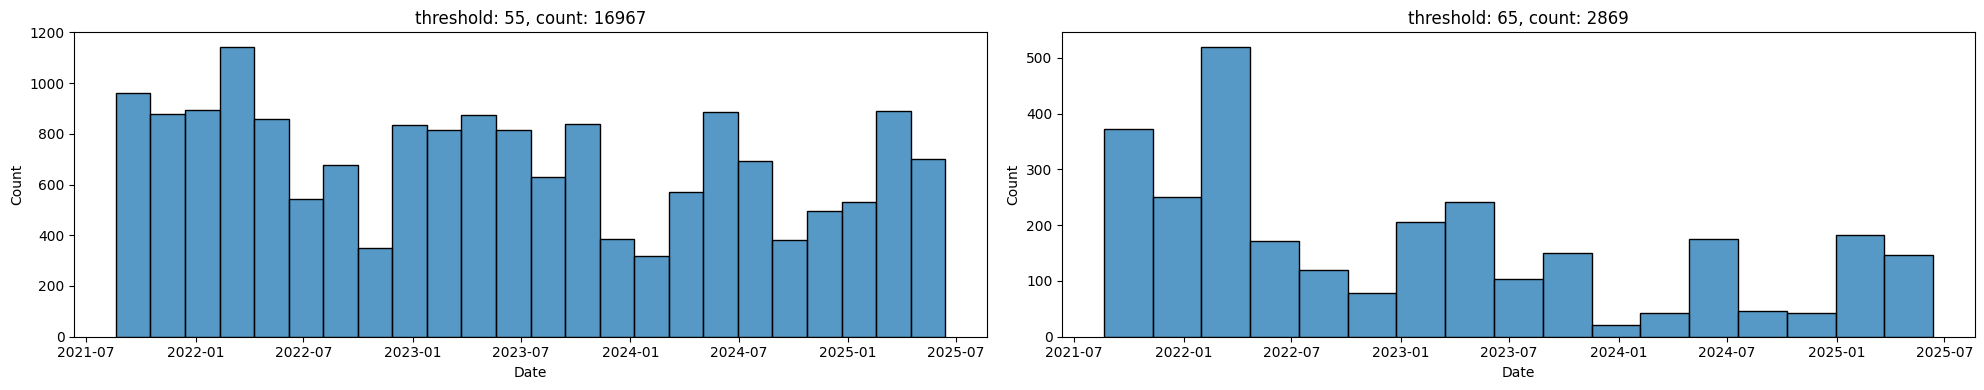

In [119]:
fig, axes = plt.subplots(1,2, figsize=(20,4))
axes = axes.reshape(-1)
for i, threshold in enumerate([55,65]):
    df_sub = new_df.query(f"(split == 'test') & (pred_rf_{threshold} == 1)")
    f= sns.histplot(df_sub['Date'], ax=axes[i]).set_title(f"threshold: {threshold}, count: {len(df_sub)}")
plt.tight_layout()

In [120]:
pred_rf_daily_positive_count = new_df.query(f"(split == 'test') & (pred_rf_65 == 1)").groupby('Date')['pred_rf_65'].count()
pred_rf_daily_positive_count.head()

,pred_rf_65
Date,
2021-08-20,3
2021-08-23,5
2021-08-24,4
2021-08-25,5
2021-08-26,4


<Axes: >

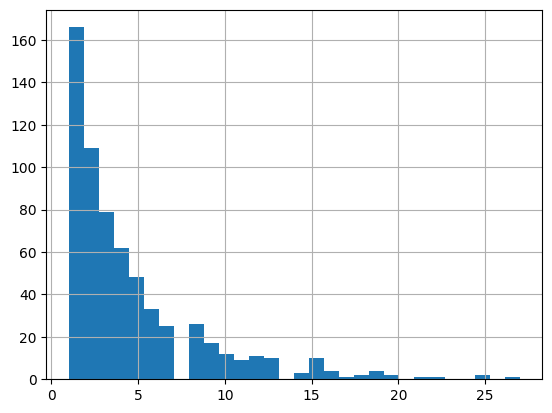

In [121]:
pred_rf_daily_positive_count.hist(bins=30)

In [122]:
# 75% cases we have not more than 6 bets of $100
pred_rf_daily_positive_count.describe()

,pred_rf_65
count,638.000000
mean,4.496865
std,4.261377
min,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,27.000000


In [123]:
new_df.columns[-10:]

Index(['pred_rf_56', 'pred_rf_57', 'pred_rf_58', 'pred_rf_59', 'pred_rf_60',
       'pred_rf_61', 'pred_rf_62', 'pred_rf_63', 'pred_rf_64', 'pred_rf_65'],
      dtype='object')

In [124]:
def calculate_simulation(pred_column, verbose=True):

    # Fin. result columns: define new records for EACH positive prediction
    new_df['gross_rev'] = new_df[pred_column] * 100 * (new_df['growth_future_30d'] - 1)
    new_df['fees'] = -new_df[pred_column] * 100 * 0.002
    new_df['net_rev'] = new_df['gross_rev'] + new_df['fees']

    df_test = new_df.query("split == 'test'") # filter records on TEST set
    df_test_pred = df_test[df_test[pred_column] == 1] # when current prediction is 1 (we invest $100 for 1 week ahead - 5 periods)

    # calculate agg. results for each PREDICTION columns (pred) on TEST
    count_investments = len(df_test_pred)
    gross_rev = df_test_pred['gross_rev'].sum()
    fees = df_test_pred['fees'].sum()
    net_rev = df_test_pred['net_rev'].sum()

    # APPROXIMATE CAPITAL REQUIRED and CAGR Calculation
    df_investments_count_daily = df_test_pred.groupby('Date', as_index=False)[pred_column].count()
    avg_investments_per_day = df_investments_count_daily[pred_column].mean()
    q75_investments_per_day = df_investments_count_daily[pred_column].quantile(0.75)  # 75% case - how many $100 investments per day do we have?
    capital = 100 * 30 * q75_investments_per_day # 30 (trading) days  in a row with positive predictions

    # CAGR: average growth per year. E.g. if you have 1.5 return (50% growth in 4 years) --> (1.5)**(1/4) = 1.106 or 10.6% average
    CAGR = ((capital + net_rev) / capital)**(1/4)

    revenue = round(100*net_rev / capital,2)

    results.append([pred_column,count_investments,int(gross_rev),int(fees),int(net_rev),avg_investments_per_day,capital,CAGR,revenue])

    # output for all predictions with some positive predictions
    if  verbose and count_investments > 1:
        print(f'Calculating sumulation for prediction {pred_column}:')
        print(f"    Count times of investment {len(df_test_pred)} out of {len(df_test)} TEST records")
        print(f"    Financial Result:")
        print(f"        Count Investments in 4 years (on TEST): {count_investments}")
        print(f"        Gross revenue: {gross_rev:.2f} $")
        print(f"        Fees: {fees:.2f} $")
        print(f"        Net revenue: {net_rev:.2f} $")
        print(f"        Fees are {-100.0*fees/gross_rev:.2f} % from Gross Revenue")
        print(f"        Capital Required : {capital} $ (Vbegin)")
        print(f"        Final value (Vbegin + Net_revenue) : {capital + net_rev:.2f} $ (Vfinal)")
        print(f"        >>> Final revenue : {revenue} %")
        print(f"        Average CAGR on TEST (4 years) : {CAGR:.4f}, or {100*(CAGR-1):.1f}% ")

        print(f"        Average daily stats: ")
        print(f"            Average net revenue per investment: {net_rev/count_investments:.2f} $ ")
        print(f"            Average investments per day: {avg_investments_per_day:.2f} $ ")
        print(f"            Q75 investments per day: {q75_investments_per_day:.2f} $")

In [125]:
results = []
pred_rf = new_df.columns[-10:]
for pred in pred_rf:
    calculate_simulation(pred)

Calculating sumulation for prediction pred_rf_56:
    Count times of investment 15199 out of 31408 TEST records
    Financial Result:
        Count Investments in 4 years (on TEST): 15199
        Gross revenue: 33363.78 $
        Fees: -3039.80 $
        Net revenue: 30418.98 $
        Fees are 9.11 % from Gross Revenue
        Capital Required : 66000.0 $ (Vbegin)
        Final value (Vbegin + Net_revenue) : 96418.98 $ (Vfinal)
        >>> Final revenue : 46.09 %
        Average CAGR on TEST (4 years) : 1.0994, or 9.9% 
        Average daily stats: 
            Average net revenue per investment: 2.00 $ 
            Average investments per day: 15.48 $ 
            Q75 investments per day: 22.00 $
Calculating sumulation for prediction pred_rf_57:
    Count times of investment 13506 out of 31408 TEST records
    Financial Result:
        Count Investments in 4 years (on TEST): 13506
        Gross revenue: 30632.34 $
        Fees: -2701.20 $
        Net revenue: 28015.14 $
        Fees 

In [126]:
results = []
for threshold in thresholds:
    calculate_simulation(f'pred_rf_{threshold}', False)
df_result = pd.DataFrame(results, columns=['prediction', 'count_investments', 'gross_rev, $', 'fees, $', 'net_rev, $', 'avg_investments_per_day','capital','CAGR', "revenue,%"])
df_result

,prediction,count_investments,"gross_rev, $","fees, $","net_rev, $",avg_investments_per_day,capital,CAGR,"revenue,%"
0,pred_rf_55,16967,36623,-3393,33335,17.242886,72000.0,1.099791,46.30
1,pred_rf_56,15199,33363,-3039,30418,15.477597,66000.0,1.099397,46.09
2,pred_rf_57,13506,30632,-2701,28015,13.838115,60000.0,1.100529,46.69
3,pred_rf_58,11847,26948,-2369,24655,12.276684,54000.0,1.098585,45.66
4,pred_rf_59,10156,23259,-2031,21291,10.769883,48000.0,1.096122,44.36
5,pred_rf_60,8671,20137,-1734,18458,9.486871,42000.0,1.095346,43.95
6,pred_rf_61,7183,17026,-1436,15634,8.190422,36000.0,1.094357,43.43
7,pred_rf_62,5866,14539,-1173,13400,7.075995,30000.0,1.096714,44.67
8,pred_rf_63,4728,12240,-945,11323,6.100645,25500.0,1.096216,44.41
9,pred_rf_64,3702,10473,-740,9754,5.206751,21000.0,1.100078,46.45


In [127]:
df_result.query('CAGR >= 1.1').sort_values(by='avg_investments_per_day')

,prediction,count_investments,"gross_rev, $","fees, $","net_rev, $",avg_investments_per_day,capital,CAGR,"revenue,%"
9,pred_rf_64,3702,10473,-740,9754,5.206751,21000.0,1.100078,46.45
2,pred_rf_57,13506,30632,-2701,28015,13.838115,60000.0,1.100529,46.69


What is the probability threshold for the best Random Forest decision rule?

**Answer:** 64%